In [2]:
import pandas as pd
import numpy as np
#from config_ import *

named13C_cellulose = "δ13C (‰ v.s.V-PDB)" ### Exceptional 
named13C_bulk = "bulk_δ13C (‰ v.s.V-PDB)"
name18O = "δ18O in ‰ vs DeltaSMOW"
named15N = "δ15N (‰ v.s. V-PDB)"
nameC_bulk ="[C_b]%"
nameC_cellulose = "[C]%"
thick = "mean_thickness_(mm)"
though = "mean_toughness_(kN/m)"
LA = "Leaf area (cm²)"
name = "genus" + "especie"

# Sumaco cleaning
data only from 2026



# Resultados Julio 2025

In [3]:
#CELLULOSA
celulosa = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Andrea-Cellulose-13C-202603.xlsx")
#275
celulosa[["plot","tree"]] = celulosa["Sample-ID"].str.split("-",expand=True)

In [4]:
#se homogeniza
celulosa["plot"]=celulosa["plot"].str.replace("p", "", regex=False)

celulosa["plot"] = celulosa["plot"].apply(
    lambda x: str(x).zfill(2) if str(x).isdigit() else x
)
celulosa["Sample-ID"] = "p"+celulosa["plot"]+"-"+celulosa["tree"]
celulosa["Sample-ID"] = celulosa["Sample-ID"].replace({
    "p9-231":"p09-231","p9-233":"p09-233","p9-235":"p09-235","p9-225":"p09-225","p9-230":"p09-230",
    "p10-3694":"p11-3694",
    "p10-3699":"p11-3699",
    "p18-3745":"p16-3745",
    "p08-3770":"p18-3770",
    "p9-3732":"p09-3732",
 "p9-3730":"p09-3730",
 "p9-3734":"p09-3734",
 "p9-3733":"p09-3733",
 "p9-3735":"p09-3735",
 "p9-3729":"p09-3729",
 "p9-3728":"p09-3728",
 "p11-3796":"p11-3696",
 "p18-3669":"p18-3769", #en esta linea no existe 18 con 36
 "p11-3701":"p11-3707",
  "p1-230":"p09-230" #no se colecto 3701
}) #missing 3703
plots = ["p09","p9","09","p10","10","p11","11","p12","12","p13","13","p16","16","p18","18"] #todos

df_filtrado = celulosa[celulosa["Sample-ID"].str.contains("|".join(plots), na=False)] #hay unas muestras que hay que limpiar
df_filtrado


,nr of samples,Sample-ID,[C] m/m in %,δ13C (‰ v.s. V-PDB),Batch,plot,tree
5,6,p09-0157,45.524787,-25.043446,AndreaChavez-Sumaco-SEQ1-HF1-C - repro,09,0157
8,9,p09-0163,46.438509,-28.063073,AndreaChavez-Sumaco-SEQ1-HF1-C - repro,09,0163
10,11,pjh-1823,46.076066,-30.518361,AndreaChavez-Sumaco-SEQ1-HF1-C - repro,jh,1823
12,13,p09-0132,45.925396,-32.676205,AndreaChavez-Sumaco-SEQ1-HF1-C - repro,09,0132
13,14,p09-0188,43.392762,-27.462748,AndreaChavez-Sumaco-SEQ1-HF1-C - repro,09,0188
...,...,...,...,...,...,...,...
249,250,pjh-3212,45.870000,-32.320000,AndreaChavez-Sumaco-SEQ3-HF1-C - repro,jh,3212
262,263,pjh-3611,45.190000,-26.200000,AndreaChavez-Sumaco-SEQ3-HF1-C - repro,jh,3611
265,266,pjh-3609,44.130000,-30.280000,AndreaChavez-Sumaco-SEQ3-HF1-C - repro,jh,3609
270,271,p11-266,43.760000,-29.600000,AndreaChavez-Sumaco-SEQ3-HF1-C - repro,11,266


In [5]:
sumaco_2006 = pd.read_excel("Sumaco_samples 2006.xlsx")


In [6]:
sumaco_2006["plot ID"] = sumaco_2006["plot ID"].astype(str).str.replace("SUM_", "p", regex=False)
sumaco_2006["Sample-ID"]=sumaco_2006["plot ID"]+"-"+sumaco_2006["treeID"].astype(str)
sumaco_2006 = sumaco_2006[["Sample-ID","family","genus","species"]]


In [7]:

SUM_2006 = pd.merge(sumaco_2006,df_filtrado, on="Sample-ID",how="left",indicator=True) #revisar q más se puede rescatar
SUM_2006 = SUM_2006.rename(columns={"plot":"Plot","tree":"old_treeID","[C] m/m in %":nameC_cellulose,
                                   "δ13C (‰ v.s. V-PDB)":named13C_cellulose })
SUM_2006 = SUM_2006.drop(columns={"nr of samples","Batch","_merge"})
SUM_2006["Year"]=2006
SUM_2006

,Sample-ID,family,genus,species,[C]%,δ13C (‰ v.s.V-PDB),Plot,old_treeID,Year
0,p09-225,Moraceae,Ficus,quijosana,42.578188,-28.691043,09,225,2006
1,p09-230,Lauraceae,Ocotea,insularis,NaN,NaN,NaN,NaN,2006
2,p09-231,Clusiaceae,Clusia,NaN,45.788101,-29.783344,09,231,2006
3,p09-233,Icacinaceae,Calatola,costaricensis,NaN,NaN,NaN,NaN,2006
4,p09-235,Icacinaceae,Calatola,costaricensis,43.261474,-30.191463,09,235,2006
5,p10-238,Clusiaceae,Chrysochlamys,membranacea,43.175043,-29.177724,10,238,2006
6,p10-239,Moraceae,Ficus,cuatrecasana,44.334499,-28.667583,10,239,2006
7,p10-240,Lauraceae,Persea,areolatocostae,44.245873,-27.855772,10,240,2006
8,p10-241,Verbenaceae,Aegiphila,NaN,44.380000,-28.450000,10,241,2006
9,p10-242,Solanaceae,Solanum,cf anisophyllum,42.914146,-29.621863,10,242,2006


In [8]:
#no_unidos = SUM_2006[SUM_2006["_merge"] == "right_only"]
#no_unidos

In [9]:
sumaco_2025 = pd.read_excel("Sumaco_17092025.xlsx",sheet_name="Rasgos_2025")
sumaco_2025 = sumaco_2025[["plot ID","treeID","new tree ID 2025","family","genus"]]
sumaco_2025["plot ID"] = sumaco_2025["plot ID"].astype(str).str.replace("SUM_", "p", regex=False)
sumaco_2025["Sample-ID"]=sumaco_2025["plot ID"]+"-"+sumaco_2025["new tree ID 2025"].astype(str)


In [10]:
SUM_2025 = pd.merge(sumaco_2025,df_filtrado, on="Sample-ID",how="left") #revisar q más se puede rescatar
SUM_2025 = SUM_2025.rename(columns={"plot ID":"Plot","treeID":"old_treeID","new tree ID 2025":"new_TreeID",
                                    "[C] m/m in %":nameC_cellulose,
                                   "δ13C (‰ v.s. V-PDB)":named13C_cellulose })
SUM_2025 = SUM_2025.drop(columns={"nr of samples","Batch","plot","tree","family"})
SUM_2025["Year"]=2025
SUM_2025#.to_excel("test.xlsx")

,Plot,old_treeID,new_TreeID,genus,Sample-ID,[C]%,δ13C (‰ v.s.V-PDB),Year
0,p09,233,3730,Calatola,p09-3730,46.640000,-30.840000,2025
1,p09,235,3733,Calatola,p09-3733,47.830000,-30.500000,2025
2,p09,NaN,3735,Allophylus,p09-3735,45.850000,-28.060000,2025
3,p09,no ID,3732,Chrysochlamys,p09-3732,44.130000,-28.990000,2025
4,p09,no ID,3729,Ficus,p09-3729,46.341632,-32.404478,2025
5,p09,no ID,3734,Allophylus,p09-3734,43.520000,-30.170000,2025
6,p09,no ID,3728,Solanum,p09-3728,41.338647,-30.555700,2025
7,p10,238,3719,Chrysochlamys,p10-3719,43.202937,-27.946246,2025
8,p10,244,3725,Casearia,p10-3725,44.895396,-29.728152,2025
9,p10,246,3723,Chrysochlamys,p10-3723,44.004689,-31.024170,2025


Unir Miscelanea

In [ ]:
mis2026 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Report 13C-pq4.xlsx")
mis2026["Sample ID"] =  mis2026["Sample ID"].astype(str).replace({"320":"p13-320","3886":"p12-3686"}) ### REVISAR HELP 3886 no existe, pero si 3686 que es de SUMACO

mis2026 = mis2026.rename(columns={"Sample ID":"Sample-ID"})#arriba todo con guion
mis2026 = mis2026.rename(columns={"[C] m/m":nameC_cellulose,"δ13C (‰ v.s. V-PDB)":named13C_cellulose})

patrones = ["09","10","13","11","12","16","18"]
regex = r"^p(" + "|".join(patrones) + r")-"
mis2026 = mis2026[mis2026["Sample-ID"].str.contains(regex, na=False)] #Filtremos solo SUMACO
mis2026= mis2026[["Sample-ID",nameC_cellulose,named13C_cellulose]]
#### separamos los de parcelas
mis2026= mis2026[mis2026["Sample-ID"] != "p09-176-ctrl"]
mis2026.loc[mis2026["Sample-ID"] == "p10-241", ["old_treeID", "Year","Plot"]] = [8878, 2006,10]
mis2026.loc[mis2026["Sample-ID"] == "p09-233", ["old_treeID", "Year","Plot"]] = [8885, 2006,9]
mis2026.loc[mis2026["Sample-ID"] == "p10-3715", ["new_TreeID", "Year","Plot"]] = [8885, 2025,10]
mis2026.loc[mis2026["Sample-ID"] == "p12-3686", ["new_TreeID", "Year","Plot"]] = [3686, 2025,12]
mis2026.loc[mis2026["Sample-ID"] == "p13-320", ["old_treeID", "Year","Plot"]] = [3715, 2006,13]
## Falta unir la informacion de las familias y generos #merge


C:\Users\selene.baez\AppData\Local\Temp\ipykernel_6236\465063612.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mis2026 = mis2026[mis2026["Sample-ID"].str.contains(regex, na=False)] #Filtremos solo SUMACO


,Sample-ID,[C]%,δ13C (‰ v.s.V-PDB),old_treeID,Year,Plot,new_TreeID
21,p13-320,0.4266,-25.52,3715.0,2006.0,13.0,NaN
27,p10-241,0.4162,-28.75,8878.0,2006.0,10.0,NaN
38,p09-233,0.4733,-29.45,8885.0,2006.0,9.0,NaN
45,p12-3686,0.4353,-33.73,NaN,2025.0,12.0,3686.0
56,p10-3715,0.3669,-29.13,NaN,2025.0,10.0,8885.0


In [ ]:
results_celulosa = pd.concat([SUM_2006,SUM_2025])
results_celulosa

,Sample-ID,family,genus,species,[C]%,δ13C (‰ v.s.V-PDB),Plot,old_treeID,Year,new_TreeID
0,p09-225,Moraceae,Ficus,quijosana,42.578188,-28.691043,09,225,2006.0,NaN
1,p09-230,Lauraceae,Ocotea,insularis,NaN,NaN,NaN,NaN,2006.0,NaN
2,p09-231,Clusiaceae,Clusia,NaN,45.788101,-29.783344,09,231,2006.0,NaN
3,p09-233,Icacinaceae,Calatola,costaricensis,NaN,NaN,NaN,NaN,2006.0,NaN
4,p09-235,Icacinaceae,Calatola,costaricensis,43.261474,-30.191463,09,235,2006.0,NaN
...,...,...,...,...,...,...,...,...,...,...
43,p18-3770,NaN,Aniba,NaN,44.275143,-30.249092,p18,no ID,2025.0,3770.0
44,p18-3766,NaN,NaN,NaN,44.582564,-31.857201,p18,no ID,2025.0,3766.0
27,p10-241,NaN,NaN,NaN,0.416200,-28.750000,10.0,8878.0,2006.0,NaN
38,p09-233,NaN,NaN,NaN,0.473300,-29.450000,9.0,8885.0,2006.0,NaN


### Faltan los resultados del bulk

# Graficos para probar

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import calculate_iWUE_sum
import elevation_dict
%run calculate_iWUE_sum
%run elevation_dict

df = results_celulosa.apply(lambda row: calculate_iWUE(row, co2_dict), axis=1)
df["Site"]="Sumaco"


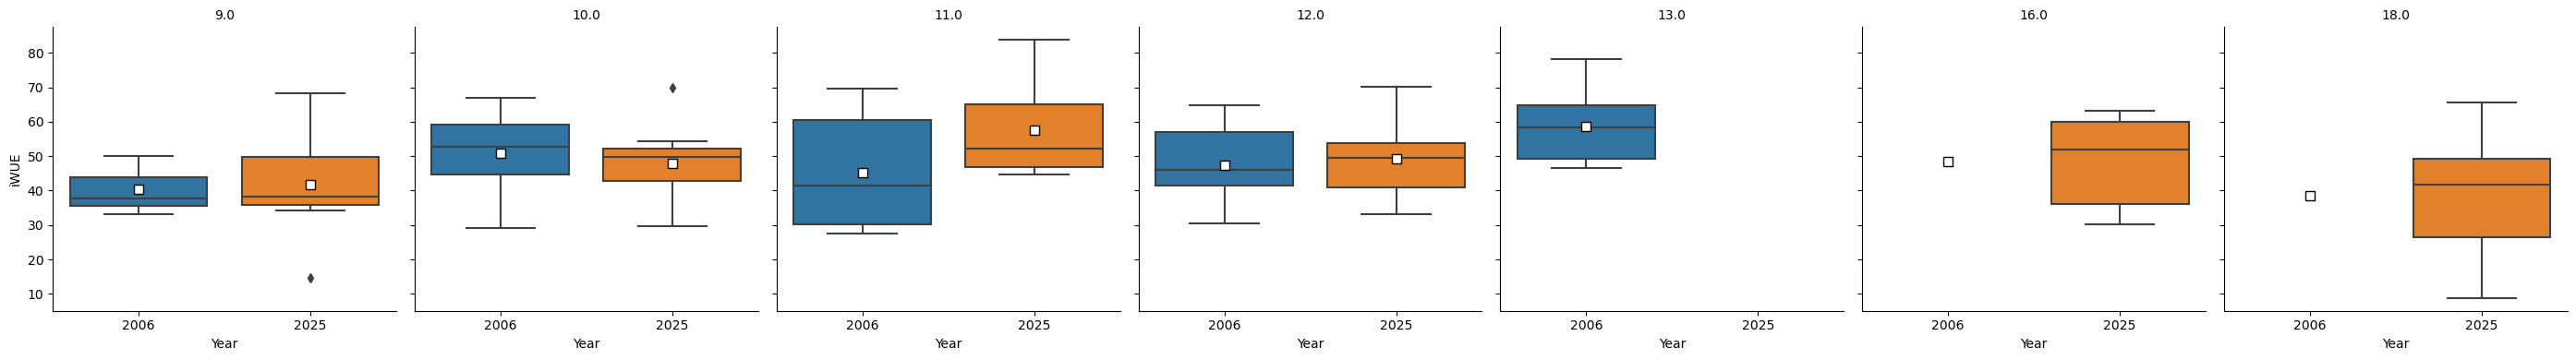

In [ ]:
df["Plot"] = (
    df["Plot"]
    .astype(str)
    .str.replace("p", "", regex=False)
)

df["Plot"] = df["Plot"].astype("float64")

df.to_excel("test.xlsx")

g = sns.catplot(
    data=df,
    x="Year",
    y= "iWUE (μmol/mol)",   # o el nombre exacto de tu columna
    col="Plot",     # facet por sitio
    kind="box",
    height=4,
    aspect=1
)

for ax in g.axes.flat:
    # obtener el valor de Elevation de este subplot
    plot = ax.get_title().split(" = ")[-1]

    subset = df[df["Plot"].astype(str) == plot]

    means = subset.groupby("Year")["iWUE (μmol/mol)"].mean()

    # posiciones en x (0,1,2,...)
    x_positions = range(len(means))

    ax.scatter(
        x_positions,
        means,
        color="white",
        edgecolor="black",
        marker="s",  # cuadrado
        s=60,
        zorder=5
    )
g.set_axis_labels("Year", "iWUE")
g.set_titles("{col_name}")  # título = nombre del sitio

plt.show()

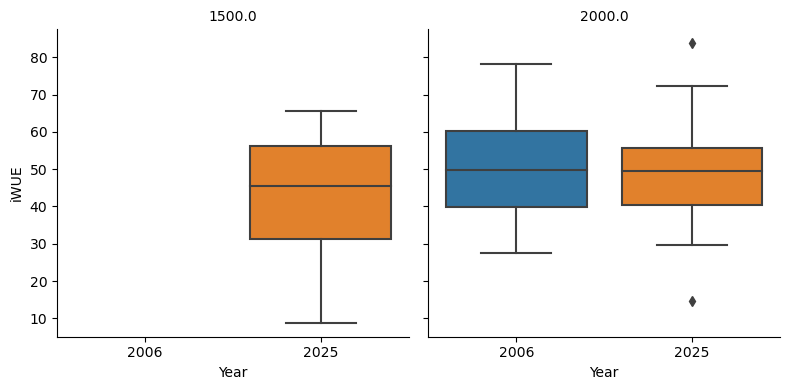

In [ ]:
df["Elevation"] = df.set_index(["Site", "Plot"]).index.map(elevation_dict)

g = sns.catplot(
    data=df,
    x="Year",
    y= "iWUE (μmol/mol)",   # o el nombre exacto de tu columna
    col="Elevation",     # facet por sitio
    kind="box",
    height=4,
    aspect=1
)

g.set_axis_labels("Year", "iWUE")
g.set_titles("{col_name}")  # título = nombre del sitio

plt.show()

In [ ]:
df["PlotID"]="SUM_"+df["Plot"].astype(str)
df.to_excel("iWUE_Sumaco.xlsx")